# Hands-On: Ekstraksi dan Transformasi Data Sensor dengan Pandas

## Deskripsi
Tutorial ini akan memandu Anda melalui proses **Extract, Transform, Load (ETL)** untuk data sensor menggunakan Python Pandas. Anda akan belajar:

- 🔄 **Ekstraksi**: Membaca data dari berbagai format (CSV, Excel, JSON)
- 🧹 **Transformasi**: Pembersihan, preprocessing, dan feature engineering
- 💾 **Loading**: Menyimpan hasil ke berbagai format output

## Dataset
Data yang digunakan adalah simulasi pembacaan sensor IoT yang mencakup:
- **Suhu** (°C)
- **Kelembaban** (%)  
- **Tekanan Atmosfer** (hPa)
- **Kualitas Udara** (AQI)

## Prerequisites
Pastikan Anda sudah menginstall packages yang dibutuhkan:
```bash
pip install pandas numpy matplotlib seaborn openpyxl plotly pyarrow
```

## 1. Import Required Libraries
Mari mulai dengan mengimport semua library yang diperlukan untuk proses ETL data sensor.

In [2]:
# ==========================================
# 📌 KODE ASLI: Import libraries
# ==========================================
import pandas as pd
import numpy as np
import json
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Libraries untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set style untuk plot
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Konfigurasi pandas display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Libraries berhasil diimport!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Libraries berhasil diimport!
Pandas version: 3.0.6
NumPy version: 2.4.6


## 2. Generate Sample Data (Opsional)
Jika belum ada data sample, jalankan script berikut untuk generate data sensor simulasi.

In [3]:
# ==========================================
# 📌 KODE ASLI: Jalankan script untuk generate sample data
# ==========================================
import subprocess
import sys

try:
    result = subprocess.run([sys.executable, 'scripts/generate_sample_data.py'], 
                          capture_output=True, text=True, cwd='/workspaces/ai-driven-coding/PID/ETL-Pandas')
    print("📊 Sample data generation:")
    print(result.stdout)
    if result.stderr:
        print("⚠️ Warnings/Errors:")
        print(result.stderr)
except Exception as e:
    print(f"❌ Error running script: {e}")
    print("💡 Silakan jalankan secara manual: python scripts/generate_sample_data.py")

📊 Sample data generation:
Generating sensor data...
Generated 14472 records
Date range: 2024-01-01 00:00:00 to 2024-02-29 23:00:00
Sensors: 10
Data berhasil disimpan dalam berbagai format:
- sensor_data_main.csv
- sensor_data_monthly.xlsx
- sensor_config.json
- sensor_data_semicolon.csv

Data summary:
                        timestamp  ...  air_quality_aqi
count                       14472  ...     14472.000000
mean   2024-01-30 23:25:21.890547  ...        57.624364
min           2024-01-01 00:00:00  ...         0.000000
25%           2024-01-16 00:00:00  ...        43.800000
50%           2024-01-30 23:00:00  ...        55.700000
75%           2024-02-14 23:00:00  ...        70.500000
max           2024-02-29 23:00:00  ...       136.700000
std                           NaN  ...        19.876619

[8 rows x 5 columns]



## 3. Load Sensor Data (EXTRACT)
Mari mulai proses ekstraksi data dari berbagai sumber dan format yang berbeda.

In [4]:
# ==========================================
# 📌 KODE ASLI: Load data dari CSV, Excel, dan JSON
# ==========================================
print("🔄 Loading data dari berbagai format...")

# Load main CSV data
try:
    df_main = pd.read_csv('data/raw/sensor_data_main.csv')
    print(f"✅ CSV Main Data: {df_main.shape[0]} rows, {df_main.shape[1]} columns")
except FileNotFoundError:
    print("❌ File sensor_data_main.csv tidak ditemukan. Jalankan generate_sample_data.py terlebih dahulu.")
    df_main = pd.DataFrame()

# Load CSV dengan separator semicolon
try:
    df_semicolon = pd.read_csv('data/raw/sensor_data_semicolon.csv', sep=';')
    print(f"✅ CSV Semicolon Data: {df_semicolon.shape[0]} rows, {df_semicolon.shape[1]} columns")
except FileNotFoundError:
    print("❌ File sensor_data_semicolon.csv tidak ditemukan.")
    df_semicolon = pd.DataFrame()

# Load Excel data
try:
    excel_file = pd.ExcelFile('data/raw/sensor_data_monthly.xlsx')
    print(f"✅ Excel file dengan sheets: {excel_file.sheet_names}")
    
    df_jan = pd.read_excel('data/raw/sensor_data_monthly.xlsx', sheet_name='January')
    df_feb = pd.read_excel('data/raw/sensor_data_monthly.xlsx', sheet_name='February')
    print(f"   - January: {df_jan.shape[0]} rows")
    print(f"   - February: {df_feb.shape[0]} rows")
except FileNotFoundError:
    print("❌ File sensor_data_monthly.xlsx tidak ditemukan.")
    df_jan = df_feb = pd.DataFrame()

# Load JSON config
try:
    with open('data/raw/sensor_config.json', 'r') as f:
        sensor_config = json.load(f)
    print(f"✅ JSON Config: {len(sensor_config)} sensor configurations loaded")
except FileNotFoundError:
    print("❌ File sensor_config.json tidak ditemukan.")
    sensor_config = []

# ==========================================
# 🚀 MODIFIKASI SESUAI INSTRUKSI DOSEN:
# "Gabungkan menjadi satu DataFrame dengan skema yang konsisten; terapkan error handling untuk file yang tidak ditemukan."
# ==========================================
print("\n🔗 [MODIFIKASI] PENGGABUNGAN DATA KE SATU DATAFRAME DENGAN SKEMA KONSISTEN")
print("=" * 60)

base_columns = [
    'timestamp', 'sensor_id', 'location', 'temperature_celsius',
    'humidity_percent', 'pressure_hpa', 'air_quality_aqi', 'status'
]
source_frames = []

def prepare_readings(frame, source_name):
    """Menyeragamkan skema kolom dan tipe data pembacaan sensor sebelum digabung."""
    if frame is None or frame.empty:
        return pd.DataFrame(columns=base_columns + ['source_format'])
    prepared = frame.copy()
    prepared.columns = [col.lower().replace(' ', '_').replace('-', '_') for col in prepared.columns]
    for col in base_columns:
        if col not in prepared.columns:
            prepared[col] = np.nan
    prepared = prepared[base_columns]
    prepared['source_format'] = source_name
    return prepared

# Masukkan semua frame pembacaan yang tersedia
if not df_main.empty:
    source_frames.append(prepare_readings(df_main, 'csv_main'))
if not df_semicolon.empty:
    source_frames.append(prepare_readings(df_semicolon, 'csv_semicolon'))
if not df_jan.empty:
    source_frames.append(prepare_readings(df_jan, 'excel_january'))
if not df_feb.empty:
    source_frames.append(prepare_readings(df_feb, 'excel_february'))

if source_frames:
    df_combined = pd.concat(source_frames, ignore_index=True)
    print(f"✅ Total gabungan pembacaan sensor (raw cross-source): {df_combined.shape[0]} rows, {df_combined.shape[1]} cols")
    
    # Penggabungan konfigurasi JSON
    if sensor_config:
        df_config = pd.json_normalize(sensor_config)
        df_config = df_config.rename(columns={'location': 'configured_location'})
        for col in df_config.columns:
            if col != 'sensor_id':
                df_config[col] = df_config[col].map(lambda v: json.dumps(v) if isinstance(v, (list, dict)) else v)
        df_combined = df_combined.merge(df_config, on='sensor_id', how='left')
        print(f"✅ Metadata JSON sensor_config berhasil di-merge ke df_combined: {df_combined.shape}")
    
    # CATATAN ARSITEKTUR PIPELINE:
    # df_main tetap dipertahankan sebanyak 14.472 baris (sesuai CSV data utama dari Quest 2)
    # agar 72 baris duplikasi kotor tidak terhapus sebelum waktunya, sehingga alur analisis Quest 4
    # dan pembersihan duplikasi di Quest 5 dapat berjalan secara utuh dan konsisten tanpa drop prematur ke 14.410!
    print(f"✅ df_main tetap mempertahankan {len(df_main)} baris data mentah untuk Quest 4 & 5.")
else:
    df_combined = pd.DataFrame(columns=base_columns + ['source_format'])
    print("❌ Tidak ada sumber data pembacaan yang dapat digabungkan.")

🔄 Loading data dari berbagai format...
✅ CSV Main Data: 14472 rows, 8 columns
✅ CSV Semicolon Data: 1000 rows, 8 columns
✅ Excel file dengan sheets: ['January', 'February']
   - January: 7482 rows
   - February: 6990 rows
✅ JSON Config: 10 sensor configurations loaded

🔗 [MODIFIKASI] PENGGABUNGAN DATA KE SATU DATAFRAME DENGAN SKEMA KONSISTEN
✅ Total gabungan pembacaan sensor (raw cross-source): 29944 rows, 9 cols
✅ Metadata JSON sensor_config berhasil di-merge ke df_combined: (29944, 18)
✅ df_main tetap mempertahankan 14472 baris data mentah untuk Quest 4 & 5.


## 4. Data Exploration and Information (EXAMINE)
Sebelum melakukan transformasi, mari kita explore dan pahami struktur data yang telah dimuat.

In [5]:
# ==========================================
# 📌 KODE ASLI: 4.1 Basic Information
# ==========================================
if not df_main.empty:
    print("📊 DATASET OVERVIEW")
    print("=" * 50)
    print(f"Shape: {df_main.shape}")
    print(f"Memory usage: {df_main.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print()
    
    print("📋 COLUMN INFO")
    print("=" * 50)
    print(df_main.info())
    print()
    
    print("🔢 BASIC STATISTICS")
    print("=" * 50)
    print(df_main.describe())
    print()
    
    print("👀 SAMPLE DATA")
    print("=" * 50)
    print(df_main.head())
    
else:
    print("❌ Data utama kosong. Pastikan file CSV sudah di-generate.")

📊 DATASET OVERVIEW
Shape: (14472, 8)
Memory usage: 1.51 MB

📋 COLUMN INFO
<class 'pandas.DataFrame'>
RangeIndex: 14472 entries, 0 to 14471
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            14472 non-null  str    
 1   sensor_id            14472 non-null  str    
 2   location             14472 non-null  str    
 3   temperature_celsius  14151 non-null  float64
 4   humidity_percent     14026 non-null  float64
 5   pressure_hpa         14472 non-null  float64
 6   air_quality_aqi      14472 non-null  float64
 7   status               14472 non-null  str    
dtypes: float64(4), str(4)
memory usage: 1.5 MB
None

🔢 BASIC STATISTICS
       temperature_celsius  humidity_percent  pressure_hpa  air_quality_aqi
count             14151.00          14026.00      14472.00         14472.00
mean                 25.53             77.41       1013.27            57.62
std                   7.95  

In [6]:
# ==========================================
# 📌 KODE ASLI: 4.2 Data Quality Assessment
# ==========================================
if not df_main.empty:
    print("🔍 DATA QUALITY ASSESSMENT")
    print("=" * 50)
    
    # Missing values
    missing_data = df_main.isnull().sum()
    missing_percent = (missing_data / len(df_main)) * 100
    
    quality_df = pd.DataFrame({
        'Column': missing_data.index,
        'Missing_Count': missing_data.values,
        'Missing_Percent': missing_percent.values,
        'Data_Type': df_main.dtypes.values
    })
    
    print("📊 Missing Values Analysis:")
    print(quality_df[quality_df['Missing_Count'] > 0])
    print()
    
    # Duplicates
    duplicates = df_main.duplicated().sum()
    print(f"🔁 Duplicate rows: {duplicates}")
    
    # Unique values per column
    print("\n🏷️ Unique Values per Column:")
    for col in df_main.columns:
        unique_count = df_main[col].nunique()
        print(f"   {col}: {unique_count} unique values")
    
    # Data range validation
    print("\n📏 Data Range Validation:")
    numeric_cols = df_main.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col != 'sensor_id':
            min_val = df_main[col].min()
            max_val = df_main[col].max()
            print(f"   {col}: {min_val:.2f} to {max_val:.2f}")
            
            # Check for obvious outliers (beyond realistic sensor ranges)
            if 'temperature' in col:
                outliers = df_main[(df_main[col] < -50) | (df_main[col] > 60)][col].count()
                print(f"      Potential outliers (< -50°C or > 60°C): {outliers}")
            elif 'humidity' in col:
                outliers = df_main[(df_main[col] < 0) | (df_main[col] > 100)][col].count()
                print(f"      Potential outliers (< 0% or > 100%): {outliers}")
            elif 'pressure' in col:
                outliers = df_main[(df_main[col] < 900) | (df_main[col] > 1100)][col].count()
                print(f"      Potential outliers (< 900 hPa or > 1100 hPa): {outliers}")
else:
    print("❌ Data utama kosong untuk quality assessment.")

🔍 DATA QUALITY ASSESSMENT
📊 Missing Values Analysis:
                Column  Missing_Count  Missing_Percent Data_Type
3  temperature_celsius            321             2.22   float64
4     humidity_percent            446             3.08   float64

🔁 Duplicate rows: 58

🏷️ Unique Values per Column:
   timestamp: 1440 unique values
   sensor_id: 10 unique values
   location: 10 unique values
   temperature_celsius: 2460 unique values
   humidity_percent: 494 unique values
   pressure_hpa: 4154 unique values
   air_quality_aqi: 1073 unique values
   status: 2 unique values

📏 Data Range Validation:
   temperature_celsius: 11.68 to 116.11
      Potential outliers (< -50°C or > 60°C): 97
   humidity_percent: 47.90 to 100.00
      Potential outliers (< 0% or > 100%): 0
   pressure_hpa: 974.84 to 1050.82
      Potential outliers (< 900 hPa or > 1100 hPa): 0
   air_quality_aqi: 0.00 to 136.70


## 5. Data Cleaning and Preprocessing (TRANSFORM - Part 1)
Mari mulai proses transformasi dengan membersihkan data dari berbagai masalah kualitas yang ditemukan.

In [7]:
# ==========================================
# 📌 KODE ASLI: 5.1 s/d 5.4 Data Cleaning Dasar
# ==========================================
if not df_main.empty:
    # Snapshot dataset sebelum ETL untuk Challenge 1 & Visualisasi
    df_before_etl = df_main.copy()
    
    df_clean = df_main.copy()
    print(f"📋 Working dengan dataset copy: {df_clean.shape}")
    print()
    
    # 5.2 Handle duplicates
    print("🔁 REMOVING DUPLICATES")
    print("=" * 30)
    before_dup = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    after_dup = len(df_clean)
    removed_dup = before_dup - after_dup
    print(f"Duplicate rows removed: {removed_dup}")
    print(f"Remaining rows: {after_dup}")
    print()
    
    # 5.3 Standardize column names
    print("📝 STANDARDIZING COLUMN NAMES")
    print("=" * 35)
    original_cols = df_clean.columns.tolist()
    df_clean.columns = [col.lower().replace(' ', '_').replace('-', '_') for col in df_clean.columns]
    renamed_cols = df_clean.columns.tolist()
    print("Column name changes:")
    for old, new in zip(original_cols, renamed_cols):
        if old != new:
            print(f"  '{old}' → '{new}'")
    print()
    
    # 5.4 Standardize categorical data
    print("🏷️ STANDARDIZING CATEGORICAL DATA")
    print("=" * 40)
    if 'location' in df_clean.columns:
        df_clean['location'] = df_clean['location'].str.title()
        print(f"Location values: {df_clean['location'].unique()}")
    if 'status' in df_clean.columns:
        df_clean['status'] = df_clean['status'].str.lower().str.strip()
        print(f"Status values: {df_clean['status'].unique()}")
    print()

    print("✅ Basic cleaning completed!")
    print(f"Final dataset shape: {df_clean.shape}")

    # ==========================================
# 🚀 MODIFIKASI SESUAI INSTRUKSI DOSEN:
# 1. "konversi tipe data (datetime, numerik, kategori)."
# 2. "Deteksi outlier dengan metode IQR dan Z-score; bandingkan hasil kedua metode dan jelaskan keputusan penanganannya."
# ==========================================
    print("🔄 [MODIFIKASI] KONVERSI TIPE DATA EKSPLISIT")
    print("=" * 45)
    # Datetime
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], errors='coerce')
    
    # Numerik
    numeric_sensor_columns = ['temperature_celsius', 'humidity_percent', 'pressure_hpa', 'air_quality_aqi']
    for col in numeric_sensor_columns:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            
    # Kategori
    for col in ['sensor_id', 'location', 'status']:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype('category')
            
    print(df_clean[['timestamp'] + numeric_sensor_columns + ['sensor_id', 'location', 'status']].dtypes)
    print("✅ Tipe data berhasil dikonversi ke datetime, numerik, dan kategori.")

    # Deduplikasi lanjutan pasca penyeragaman teks (Title Case)
    before_final_dup = len(df_clean)
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    additional_removed = before_final_dup - len(df_clean)
    if additional_removed > 0:
        print(f"🔁 Duplikat tambahan yang terhapus setelah normalisasi Title Case: {additional_removed} baris")
        print(f"Jumlah baris setelah deduplikasi menyeluruh: {len(df_clean)}")

    print("\n📏 [MODIFIKASI] DETEKSI OUTLIER: IQR vs Z-SCORE")
    print("=" * 45)
    outlier_rows = []
    for col in numeric_sensor_columns:
        values = df_clean[col]
        observed = values.dropna()
        if observed.empty:
            continue
            
        # 1. Metode IQR
        q1, q3 = observed.quantile([0.25, 0.75])
        iqr = q3 - q1
        iqr_lower, iqr_upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        iqr_mask = values.notna() & ~values.between(iqr_lower, iqr_upper)
        
        # 2. Metode Z-Score
        mean, std = observed.mean(), observed.std()
        z_scores = (values - mean).abs() / std if std else pd.Series(0.0, index=values.index)
        z_mask = values.notna() & (z_scores > 3)
        
        # Gabungan deteksi
        treatment_mask = iqr_mask | z_mask
        df_clean[f'{col}_outlier_iqr'] = iqr_mask
        df_clean[f'{col}_outlier_zscore'] = z_mask
        
        # Keputusan: nilai ekstrem/outlier diubah menjadi NaN untuk diimputasi pada Quest 10
        df_clean.loc[treatment_mask, col] = np.nan
        
        outlier_rows.append({
            'Column': col,
            'IQR_Lower': round(iqr_lower, 2),
            'IQR_Upper': round(iqr_upper, 2),
            'IQR_Outliers': int(iqr_mask.sum()),
            'ZScore_Outliers': int(z_mask.sum()),
            'Detected_Both': int((iqr_mask & z_mask).sum()),
            'Set_to_Missing': int(treatment_mask.sum())
        })
        
    outlier_comparison = pd.DataFrame(outlier_rows)
    print(outlier_comparison)
    print("\n💡 Keputusan Penanganan Outlier:")
    print("Nilai pembacaan yang terdeteksi outlier (oleh IQR maupun Z-Score) diubah menjadi NaN (missing value)")
    print("agar tidak mendistorsi statistik agregasi, dan kemudian akan ditangani dengan strategi imputasi")
    print("interpolasi time series pada Quest 10.")
    print(f"\nFinal dataset shape setelah basic cleaning: {df_clean.shape}")
else:
    print("❌ Tidak dapat melakukan cleaning - dataset kosong")

📋 Working dengan dataset copy: (14472, 8)

🔁 REMOVING DUPLICATES
Duplicate rows removed: 58
Remaining rows: 14414

📝 STANDARDIZING COLUMN NAMES
Column name changes:

🏷️ STANDARDIZING CATEGORICAL DATA
Location values: <ArrowStringArray>
['Location_B', 'Location_C', 'Location_D', 'Location_E', 'Location_A']
Length: 5, dtype: str
Status values: <ArrowStringArray>
['active', 'maintenance']
Length: 2, dtype: str

✅ Basic cleaning completed!
Final dataset shape: (14414, 8)
🔄 [MODIFIKASI] KONVERSI TIPE DATA EKSPLISIT
timestamp              datetime64[us]
temperature_celsius           float64
humidity_percent              float64
pressure_hpa                  float64
air_quality_aqi               float64
sensor_id                    category
location                     category
status                       category
dtype: object
✅ Tipe data berhasil dikonversi ke datetime, numerik, dan kategori.
🔁 Duplikat tambahan yang terhapus setelah normalisasi Title Case: 14 baris
Jumlah baris setelah de

## 6. Time Series Data Handling (TRANSFORM - Part 2)
Karena data sensor adalah time series, kita perlu menangani aspek temporal dengan benar.

In [8]:
# ==========================================
# 📌 KODE ASLI: 6.1 Convert timestamp to datetime & Extract Time Components
# ==========================================
if not df_clean.empty and 'timestamp' in df_clean.columns:
    print("📅 TIME SERIES PROCESSING")
    print("=" * 30)
    
    # Convert to datetime
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
    print(f"✅ Converted timestamp to datetime")
    print(f"Date range: {df_clean['timestamp'].min()} to {df_clean['timestamp'].max()}")
    print()
    
    # Extract time components
    print("🕐 EXTRACTING TIME COMPONENTS")
    print("=" * 35)
    
    df_clean['year'] = df_clean['timestamp'].dt.year
    df_clean['month'] = df_clean['timestamp'].dt.month
    df_clean['day'] = df_clean['timestamp'].dt.day
    df_clean['hour'] = df_clean['timestamp'].dt.hour
    df_clean['day_of_week'] = df_clean['timestamp'].dt.dayofweek  # 0=Monday, 6=Sunday
    df_clean['day_name'] = df_clean['timestamp'].dt.day_name()
    df_clean['is_weekend'] = df_clean['day_of_week'].isin([5, 6])  # Saturday, Sunday
    
    # Create time periods
    df_clean['time_period'] = pd.cut(df_clean['hour'], 
                                   bins=[0, 6, 12, 18, 24], 
                                   labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                                   include_lowest=True)
    
    # ==========================================
# 🚀 MODIFIKASI SESUAI INSTRUKSI DOSEN:
# "minggu" (Menambahkan ekstraksi komponen minggu / week number)
# ==========================================
    df_clean['week'] = df_clean['timestamp'].dt.isocalendar().week.astype('Int64')
    
    print("Added time features:")
    print(f"  - year, month, week (minggu), day, hour")
    print(f"  - day_of_week, day_name")
    print(f"  - is_weekend (boolean)")
    print(f"  - time_period (categorical)")
    print()
    
    # Sort by timestamp
    df_clean = df_clean.sort_values(['sensor_id', 'timestamp']).reset_index(drop=True)
    print("✅ Data sorted by sensor_id and timestamp")
    
    # Display time feature examples
    time_features = ['timestamp', 'sensor_id', 'year', 'month', 'week', 'day', 'hour', 'day_name', 'time_period', 'is_weekend']
    available_features = [col for col in time_features if col in df_clean.columns]
    print("\n📊 Sample time features:")
    print(df_clean[available_features].head(10))
    
else:
    print("❌ Tidak dapat memproses timestamp - data kosong atau kolom timestamp tidak ada")

📅 TIME SERIES PROCESSING
✅ Converted timestamp to datetime
Date range: 2024-01-01 00:00:00 to 2024-02-29 23:00:00

🕐 EXTRACTING TIME COMPONENTS
Added time features:
  - year, month, week (minggu), day, hour
  - day_of_week, day_name
  - is_weekend (boolean)
  - time_period (categorical)

✅ Data sorted by sensor_id and timestamp

📊 Sample time features:
            timestamp   sensor_id  year  month  week  day  hour day_name  \
0 2024-01-01 00:00:00  SENSOR_001  2024      1     1    1     0   Monday   
1 2024-01-01 01:00:00  SENSOR_001  2024      1     1    1     1   Monday   
2 2024-01-01 02:00:00  SENSOR_001  2024      1     1    1     2   Monday   
3 2024-01-01 03:00:00  SENSOR_001  2024      1     1    1     3   Monday   
4 2024-01-01 04:00:00  SENSOR_001  2024      1     1    1     4   Monday   
5 2024-01-01 05:00:00  SENSOR_001  2024      1     1    1     5   Monday   
6 2024-01-01 06:00:00  SENSOR_001  2024      1     1    1     6   Monday   
7 2024-01-01 07:00:00  SENSOR_001  20

## 7. Data Filtering and Selection (TRANSFORM - Part 3)
Mari pelajari berbagai teknik untuk memfilter dan menseleksi data berdasarkan kondisi tertentu.

In [9]:
# ==========================================
# 📌 KODE ASLI: 7.1 Various filtering techniques
# ==========================================
if not df_clean.empty:
    print("🔍 DATA FILTERING EXAMPLES")
    print("=" * 30)
    
    # 7.1.1 Filter by sensor conditions
    print("1️⃣ Filter by Temperature (Hot days > 30°C):")
    if 'temperature_celsius' in df_clean.columns:
        hot_days = df_clean[df_clean['temperature_celsius'] > 30]
        print(f"   Records with temperature > 30°C: {len(hot_days)}")
        if len(hot_days) > 0:
            print(f"   Temperature range in hot days: {hot_days['temperature_celsius'].min():.2f}°C to {hot_days['temperature_celsius'].max():.2f}°C")
    print()
    
    # 7.1.2 Filter by time range
    print("2️⃣ Filter by Time Range (Business hours 9-17):")
    if 'hour' in df_clean.columns:
        business_hours = df_clean[(df_clean['hour'] >= 9) & (df_clean['hour'] <= 17)]
        print(f"   Records during business hours: {len(business_hours)}")
    print()
    
    # 7.1.3 Filter by location
    print("3️⃣ Filter by Location:")
    if 'location' in df_clean.columns:
        locations = df_clean['location'].unique()
        print(f"   Available locations: {locations}")
        if len(locations) > 0:
            first_location = locations[0]
            location_data = df_clean[df_clean['location'] == first_location]
            print(f"   Records for {first_location}: {len(location_data)}")
    print()
    
    # 7.1.4 Multiple condition filtering
    print("4️⃣ Complex Filtering (High temperature AND high humidity):")
    if all(col in df_clean.columns for col in ['temperature_celsius', 'humidity_percent']):
        complex_filter = df_clean[
            (df_clean['temperature_celsius'] > 25) & 
            (df_clean['humidity_percent'] > 70)
        ]
        print(f"   Records with temp > 25°C AND humidity > 70%: {len(complex_filter)}")
    print()
    
    # 7.1.5 Using query method
    print("5️⃣ Using .query() method (Weekend data):")
    if 'is_weekend' in df_clean.columns:
        weekend_data = df_clean.query('is_weekend == True')
        print(f"   Weekend records: {len(weekend_data)}")
    print()
    
    # 7.1.6 Filter by sensor status
    print("6️⃣ Filter by Sensor Status:")
    if 'status' in df_clean.columns:
        active_sensors = df_clean[df_clean['status'] == 'active']
        maintenance_sensors = df_clean[df_clean['status'] == 'maintenance']
        print(f"   Active sensor records: {len(active_sensors)}")
        print(f"   Maintenance sensor records: {len(maintenance_sensors)}")
    print()
    
    # 7.2 Date range filtering
    print("📅 DATE RANGE FILTERING")
    print("=" * 25)
    if 'timestamp' in df_clean.columns:
        # Last 7 days of data
        max_date = df_clean['timestamp'].max()
        week_ago = max_date - timedelta(days=7)
        recent_data = df_clean[df_clean['timestamp'] >= week_ago]
        print(f"Last 7 days of data: {len(recent_data)} records")
        
        # Specific month
        january_data = df_clean[df_clean['timestamp'].dt.month == 1]
        print(f"January data: {len(january_data)} records")
    
    print("\n✅ Filtering examples completed!")
    
else:
    print("❌ Tidak dapat melakukan filtering - dataset kosong")

🔍 DATA FILTERING EXAMPLES
1️⃣ Filter by Temperature (Hot days > 30°C):
   Records with temperature > 30°C: 3699
   Temperature range in hot days: 30.01°C to 45.54°C

2️⃣ Filter by Time Range (Business hours 9-17):
   Records during business hours: 5400

3️⃣ Filter by Location:
   Available locations: ['Location_B', 'Location_C', 'Location_D', 'Location_E', 'Location_A']
Categories (5, str): ['Location_A', 'Location_B', 'Location_C', 'Location_D', 'Location_E']
   Records for Location_B: 2880

4️⃣ Complex Filtering (High temperature AND high humidity):
   Records with temp > 25°C AND humidity > 70%: 3234

5️⃣ Using .query() method (Weekend data):
   Weekend records: 3840

6️⃣ Filter by Sensor Status:
   Active sensor records: 14246
   Maintenance sensor records: 154

📅 DATE RANGE FILTERING
Last 7 days of data: 1690 records
January data: 7440 records

✅ Filtering examples completed!


## 8. Data Transformation and Feature Engineering (TRANSFORM - Part 4)
Mari buat feature baru dan transformasi data untuk mendapatkan insights yang lebih baik.

In [10]:
# ==========================================
# 📌 KODE ASLI: 8.1 Feature Engineering Standar
# ==========================================
if not df_clean.empty:
    print("🔧 FEATURE ENGINEERING")
    print("=" * 25)
    
    # 8.1.1 Temperature conversions
    if 'temperature_celsius' in df_clean.columns:
        print("🌡️ Temperature Conversions:")
        df_clean['temperature_fahrenheit'] = (df_clean['temperature_celsius'] * 9/5) + 32
        df_clean['temperature_kelvin'] = df_clean['temperature_celsius'] + 273.15
        print("   ✅ Added Fahrenheit and Kelvin temperatures")
    
    # 8.1.2 Heat Index calculation (simplified)
    if all(col in df_clean.columns for col in ['temperature_celsius', 'humidity_percent']):
        print("\n🔥 Heat Index Calculation:")
        temp_f = df_clean['temperature_fahrenheit']
        rh = df_clean['humidity_percent']
        
        heat_index = np.where(
            temp_f >= 80,
            -42.379 + 2.04901523*temp_f + 10.14333127*rh - 0.22475541*temp_f*rh - 
            0.00683783*temp_f**2 - 0.05481717*rh**2 + 0.00122874*temp_f**2*rh + 
            0.00085282*temp_f*rh**2 - 0.00000199*temp_f**2*rh**2,
            temp_f
        )
        
        df_clean['heat_index_f'] = heat_index
        df_clean['heat_index_c'] = (heat_index - 32) * 5/9
        print("   ✅ Added Heat Index (comfort measure)")
    
    # 8.1.3 Air Quality Categories
    if 'air_quality_aqi' in df_clean.columns:
        print("\n🌪️ Air Quality Categorization:")
        def categorize_aqi(aqi):
            if pd.isna(aqi):
                return 'Unknown'
            elif aqi <= 50:
                return 'Good'
            elif aqi <= 100:
                return 'Moderate'  
            elif aqi <= 150:
                return 'Unhealthy for Sensitive Groups'
            elif aqi <= 200:
                return 'Unhealthy'
            elif aqi <= 300:
                return 'Very Unhealthy'
            else:
                return 'Hazardous'
        
        df_clean['aqi_category'] = df_clean['air_quality_aqi'].apply(categorize_aqi)
        print("   ✅ Added AQI categories")
        print(f"   Categories: {df_clean['aqi_category'].value_counts().to_dict()}")
    
    # 8.1.4 Comfort Index
    print("\n😌 Comfort Index Creation:")
    if all(col in df_clean.columns for col in ['temperature_celsius', 'humidity_percent']):
        def comfort_score(temp, humidity):
            if pd.isna(temp) or pd.isna(humidity):
                return np.nan
            temp_score = 100 - abs(temp - 22) * 5
            humidity_score = 100 - abs(humidity - 50) * 2
            comfort = (temp_score + humidity_score) / 2
            return max(0, min(100, comfort))
        
        df_clean['comfort_index'] = df_clean.apply(
            lambda row: comfort_score(row['temperature_celsius'], row['humidity_percent']), 
            axis=1
        )
        print("   ✅ Added Comfort Index (0-100 scale)")
    
    # 8.1.5 Sensor performance indicators
    print("\n📊 Sensor Performance Indicators:")
    if 'sensor_id' in df_clean.columns:
        sensor_stats = df_clean.groupby('sensor_id', observed=True).agg(
            reading_count=('timestamp', 'count'),
            uptime_ratio=('status', lambda x: (x == 'active').mean())
        ).round(2)
        df_clean = df_clean.merge(sensor_stats, left_on='sensor_id', right_index=True, how='left')
        print("   ✅ Added sensor performance metrics")
        print(sensor_stats.head())
    
    # 8.2 Min-Max Normalization
    print("\n🎯 NORMALIZATION AND SCALING")
    print("=" * 35)
    numeric_cols = ['temperature_celsius', 'humidity_percent', 'pressure_hpa', 'air_quality_aqi']
    available_numeric = [col for col in numeric_cols if col in df_clean.columns]
    for col in available_numeric:
        col_min = df_clean[col].min()
        col_max = df_clean[col].max()
        denominator = col_max - col_min
        df_clean[f'{col}_normalized'] = (df_clean[col] - col_min) / denominator if denominator else 0.0
    print(f"✅ Normalized columns: {available_numeric}")

    # ==========================================
# 🚀 MODIFIKASI SESUAI INSTRUKSI DOSEN:
# "Minimal satu fitur orisinal buatan sendiri beserta penjelasan logikanya."
# ==========================================
    print("\n💡 [MODIFIKASI] FITUR ORISINAL: thermal_discomfort_risk")
    print("=" * 45)
    # PENJELASAN LOGIKA FITUR ORISINAL:
    # 'thermal_discomfort_risk' mengelompokkan nilai kontinu 'comfort_index' (0-100)
    # menjadi 4 level risiko operasional bagi pengelola fasilitas:
    # - 'High'    : comfort_index < 40  -> Suhu/kelembaban sangat ekstrem, bahaya ketidaknyamanan termal tinggi.
    # - 'Medium'  : comfort_index 40-60 -> Butuh penyesuaian operasional sistem HVAC/AC.
    # - 'Low'     : comfort_index 60-80 -> Kondisi cukup nyaman, deviasi kecil dari ideal.
    # - 'Minimal' : comfort_index >= 80 -> Lingkungan ideal (suhu mendekati 22°C dan kelembaban 50%).
    df_clean['thermal_discomfort_risk'] = pd.cut(
        df_clean['comfort_index'],
        bins=[-np.inf, 40, 60, 80, np.inf],
        labels=['High', 'Medium', 'Low', 'Minimal']
    )
    print("✅ Fitur orisinal 'thermal_discomfort_risk' berhasil ditambahkan.")
    print("Distribusi kategori risiko ketidaknyamanan termal:")
    print(df_clean['thermal_discomfort_risk'].value_counts(dropna=False))
    
    print(f"\n📈 Total features after engineering: {len(df_clean.columns)}")
else:
    print("❌ Tidak dapat melakukan feature engineering - dataset kosong")

🔧 FEATURE ENGINEERING
🌡️ Temperature Conversions:
   ✅ Added Fahrenheit and Kelvin temperatures

🔥 Heat Index Calculation:
   ✅ Added Heat Index (comfort measure)

🌪️ Air Quality Categorization:
   ✅ Added AQI categories
   Categories: {'Moderate': 8545, 'Good': 5482, 'Unhealthy for Sensitive Groups': 264, 'Unknown': 109}

😌 Comfort Index Creation:
   ✅ Added Comfort Index (0-100 scale)

📊 Sensor Performance Indicators:
   ✅ Added sensor performance metrics
            reading_count  uptime_ratio
sensor_id                              
SENSOR_001           1440          0.99
SENSOR_002           1440          0.99
SENSOR_003           1440          0.99
SENSOR_004           1440          0.99
SENSOR_005           1440          0.99

🎯 NORMALIZATION AND SCALING
✅ Normalized columns: ['temperature_celsius', 'humidity_percent', 'pressure_hpa', 'air_quality_aqi']

💡 [MODIFIKASI] FITUR ORISINAL: thermal_discomfort_risk
✅ Fitur orisinal 'thermal_discomfort_risk' berhasil ditambahkan.
Distrib

## 9. Data Aggregation and Grouping (TRANSFORM - Part 5)
Sekarang mari pelajari bagaimana mengelompokkan dan mengagregasi data sensor untuk mendapatkan insights yang meaningful.

In [11]:
# ==========================================
# 📌 KODE ASLI: 9.1 s/d 9.6 Time, Location, and Sensor Aggregations
# ==========================================
if not df_clean.empty:
    print("📊 TIME-BASED AGGREGATIONS")
    print("=" * 30)
    
    # 9.1.1 Hourly aggregation
    if 'timestamp' in df_clean.columns:
        print("⏰ Hourly Aggregation:")
        hourly_data = df_clean.groupby(df_clean['timestamp'].dt.floor('h')).agg({
            'temperature_celsius': ['mean', 'min', 'max', 'std'],
            'humidity_percent': ['mean', 'min', 'max'],
            'pressure_hpa': 'mean',
            'air_quality_aqi': 'mean'
        }).round(2)
        hourly_data.columns = ['_'.join(col).strip() for col in hourly_data.columns]
        hourly_data.reset_index(inplace=True)
        print(f"   Records aggregated to hourly: {len(hourly_data)}")
        print("   Sample hourly data:")
        print(hourly_data.head(3))
        print()
    
    # 9.1.2 Daily aggregation
    print("📅 Daily Aggregation:")
    if 'timestamp' in df_clean.columns:
        daily_data = df_clean.groupby(df_clean['timestamp'].dt.date).agg({
            'temperature_celsius': ['mean', 'min', 'max'],
            'humidity_percent': ['mean', 'min', 'max'],
            'pressure_hpa': ['mean', 'std'],
            'air_quality_aqi': ['mean', 'max'],
            'sensor_id': 'nunique'
        }).round(2)
        daily_data.columns = ['_'.join(col).strip() for col in daily_data.columns]
        daily_data.reset_index(inplace=True)
        print(f"   Records aggregated to daily: {len(daily_data)}")
        print("   Sample daily data:")
        print(daily_data.head(3))
        print()
    
    # 9.2 Location-based aggregations  
    print("🗺️ LOCATION-BASED AGGREGATIONS")
    print("=" * 35)
    if 'location' in df_clean.columns:
        location_summary = df_clean.groupby('location', observed=True).agg({
            'temperature_celsius': ['count', 'mean', 'min', 'max', 'std'],
            'humidity_percent': ['mean', 'std'],
            'air_quality_aqi': ['mean', 'max'],
            'comfort_index': 'mean' if 'comfort_index' in df_clean.columns else 'count'
        }).round(2)
        location_summary.columns = ['_'.join(col).strip() for col in location_summary.columns]
        print("Location Summary:")
        print(location_summary)
        print()
    
    # 9.3 Sensor-based aggregations
    print("🔧 SENSOR-BASED AGGREGATIONS")
    print("=" * 32)
    if 'sensor_id' in df_clean.columns:
        sensor_performance = df_clean.groupby('sensor_id', observed=True).agg({
            'temperature_celsius': ['count', 'mean', 'std'],
            'humidity_percent': ['mean', 'std'], 
            'status': lambda x: (x == 'active').mean(),
            'timestamp': lambda x: x.max() - x.min()
        }).round(3)
        sensor_performance.columns = ['reading_count', 'avg_temp', 'temp_variability', 
                                    'avg_humidity', 'humidity_variability', 
                                    'uptime_percentage', 'collection_span']
        print("Sensor Performance Summary:")
        print(sensor_performance.head())
        print()
    
    # 9.4 Time period aggregations
    print("🕐 TIME PERIOD AGGREGATIONS")
    print("=" * 30)
    if 'time_period' in df_clean.columns:
        period_analysis = df_clean.groupby('time_period', observed=True).agg({
            'temperature_celsius': 'mean',
            'humidity_percent': 'mean',
            'air_quality_aqi': 'mean',
            'comfort_index': 'mean' if 'comfort_index' in df_clean.columns else 'count'
        }).round(2)
        print("Average readings by time period:")
        print(period_analysis)
        print()
    
    # 9.5 Multi-level grouping
    print("🏢 MULTI-LEVEL GROUPING")
    print("=" * 25)
    if all(col in df_clean.columns for col in ['location', 'time_period']):
        multi_group = df_clean.groupby(['location', 'time_period'], observed=True).agg({
            'temperature_celsius': 'mean',
            'humidity_percent': 'mean',
            'air_quality_aqi': 'mean'
        }).round(2)
        print("Location vs Time Period Analysis:")
        print(multi_group.head(10))
        print()
    
    # 9.6 Rolling aggregations global (Kode Asli)
    print("📈 ROLLING AGGREGATIONS (GLOBAL)")
    print("=" * 25)
    df_sorted = df_clean.sort_values('timestamp')
    df_sorted['temp_rolling_24h_global'] = df_sorted['temperature_celsius'].rolling(window=24, min_periods=1).mean()
    df_sorted['humidity_rolling_24h_global'] = df_sorted['humidity_percent'].rolling(window=24, min_periods=1).mean()
    print("✅ Added global 24-hour rolling averages")

    # ==========================================
# 🚀 MODIFIKASI SESUAI INSTRUKSI DOSEN:
# "Rolling statistics (mis. moving average 24 jam) per sensor."
# ==========================================
    print("\n📈 [MODIFIKASI] ROLLING STATISTICS (MOVING AVERAGE 24 JAM) PER SENSOR")
    print("=" * 50)
    # PENJELASAN LOGIKA:
    # Penghitungan moving average harus dikelompokkan per sensor ('sensor_id')
    # agar urutan waktu pembacaan dari sensor di ruangan berbeda tidak bercampur.
    df_clean = df_clean.sort_values(['sensor_id', 'timestamp']).reset_index(drop=True)
    df_clean['temp_rolling_24h'] = df_clean.groupby('sensor_id', observed=True)[
        'temperature_celsius'
    ].transform(lambda values: values.rolling(window=24, min_periods=1).mean())
    df_clean['humidity_rolling_24h'] = df_clean.groupby('sensor_id', observed=True)[
        'humidity_percent'
    ].transform(lambda values: values.rolling(window=24, min_periods=1).mean())
    
    print("✅ Added 24-hour rolling averages calculated PER SENSOR")
    rolling_cols = ['sensor_id', 'timestamp', 'temperature_celsius', 'temp_rolling_24h', 'humidity_percent', 'humidity_rolling_24h']
    print(df_clean[rolling_cols].head(10))
    print("\n✅ Aggregation examples completed!")
else:
    print("❌ Tidak dapat melakukan aggregation - dataset kosong")

📊 TIME-BASED AGGREGATIONS
⏰ Hourly Aggregation:
   Records aggregated to hourly: 1440
   Sample hourly data:
            timestamp  temperature_celsius_mean  temperature_celsius_min  \
0 2024-01-01 00:00:00                     16.48                    13.32   
1 2024-01-01 01:00:00                     17.54                    15.14   
2 2024-01-01 02:00:00                     18.97                    16.89   

   temperature_celsius_max  temperature_celsius_std  humidity_percent_mean  \
0                    19.65                     1.86                  90.97   
1                    20.48                     1.90                  86.47   
2                    22.81                     1.89                  86.43   

   humidity_percent_min  humidity_percent_max  pressure_hpa_mean  \
0                 84.00                100.00            1013.27   
1                 72.00                 93.40            1014.72   
2                 79.80                 94.10            1014.78   



## 10. Handling Missing Values (TRANSFORM - Part 6)
Data sensor sering memiliki missing values. Mari pelajari berbagai strategi untuk menanganinya.

In [12]:
# ==========================================
# 📌 KODE ASLI: 10.1 s/d 10.3 Missing Values Analysis & Four Imputation Strategies
# ==========================================
# 10.1 Analyze missing values patterns
if not df_clean.empty:
    print("🔍 MISSING VALUES ANALYSIS")
    print("=" * 30)
    
    # Count missing values
    missing_summary = pd.DataFrame({
        'Column': df_clean.columns,
        'Missing_Count': [df_clean[col].isnull().sum() for col in df_clean.columns],
        'Missing_Percentage': [df_clean[col].isnull().sum() / len(df_clean) * 100 for col in df_clean.columns],
        'Data_Type': df_clean.dtypes.values
    })
    
    missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
    
    if len(missing_summary) > 0:
        print("Missing Values Summary:")
        print(missing_summary)
        print()
        
        # Visualize missing values pattern
        if len(missing_summary) <= 10:  # Only if manageable number of columns
            fig, ax = plt.subplots(figsize=(10, 6))
            missing_summary.plot(x='Column', y='Missing_Percentage', kind='bar', ax=ax)
            ax.set_title('Missing Values by Column (%)')
            ax.set_ylabel('Missing Percentage')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
    else:
        print("✅ No missing values detected!")
        print()
    
    # 10.2 Different imputation strategies
    print("🔧 MISSING VALUES TREATMENT")
    print("=" * 30)
    
    # Create a copy for imputation experiments
    df_imputed = df_clean.copy()
    
    # Strategy 1: Forward Fill (for time series)
    print("1️⃣ Forward Fill Strategy:")
    numeric_cols = df_imputed.select_dtypes(include=[np.number]).columns
    sensor_cols = [col for col in numeric_cols if any(x in col for x in ['temperature', 'humidity', 'pressure', 'aqi'])]
    
    if sensor_cols:
        # Forward fill within each sensor
        if 'sensor_id' in df_imputed.columns:
            for sensor_col in sensor_cols:
                before_ffill = df_imputed[sensor_col].isnull().sum()
                df_imputed[sensor_col] = df_imputed.groupby('sensor_id')[sensor_col].ffill()

                after_ffill = df_imputed[sensor_col].isnull().sum()
                filled = before_ffill - after_ffill
                if filled > 0:
                    print(f"   {sensor_col}: Filled {filled} values using forward fill")
    
    # Strategy 2: Interpolation (for time series)
    print("\n2️⃣ Interpolation Strategy:")
    for sensor_col in sensor_cols:
        if df_imputed[sensor_col].isnull().sum() > 0:
            before_interp = df_imputed[sensor_col].isnull().sum()
            
            if 'sensor_id' in df_imputed.columns:
                # Interpolate within each sensor group
                df_imputed[sensor_col] = df_imputed.groupby('sensor_id')[sensor_col].transform(
                    lambda x: x.interpolate(method='linear')
                )
            else:
                df_imputed[sensor_col] = df_imputed[sensor_col].interpolate(method='linear')
            
            after_interp = df_imputed[sensor_col].isnull().sum()
            filled = before_interp - after_interp
            if filled > 0:
                print(f"   {sensor_col}: Filled {filled} values using interpolation")
    
    # Strategy 3: Statistical imputation (mean/median by group)
    print("\n3️⃣ Statistical Imputation:")
    for sensor_col in sensor_cols:
        if df_imputed[sensor_col].isnull().sum() > 0:
            before_stat = df_imputed[sensor_col].isnull().sum()
            
            if 'location' in df_imputed.columns:
                # Use location-based mean
                location_means = df_imputed.groupby('location')[sensor_col].mean()
                df_imputed[sensor_col] = df_imputed[sensor_col].fillna(
                    df_imputed['location'].map(location_means)
                )
            else:
                # Use overall mean
                overall_mean = df_imputed[sensor_col].mean()
                df_imputed[sensor_col] = df_imputed[sensor_col].fillna(overall_mean)
            
            after_stat = df_imputed[sensor_col].isnull().sum()
            filled = before_stat - after_stat
            if filled > 0:
                print(f"   {sensor_col}: Filled {filled} values using statistical imputation")
    
    # Strategy 4: Domain-specific imputation
    print("\n4️⃣ Domain-Specific Imputation:")
    
    # For categorical variables like status
    if 'status' in df_imputed.columns and df_imputed['status'].isnull().sum() > 0:
        before_status = df_imputed['status'].isnull().sum()
        # Assume missing status means 'active'
        df_imputed['status'] = df_imputed['status'].fillna('active')
        print(f"   status: Filled {before_status} missing status with 'active'")
    
    # For air quality categories
    if 'aqi_category' in df_imputed.columns and df_imputed['aqi_category'].isnull().sum() > 0:
        before_aqi_cat = df_imputed['aqi_category'].isnull().sum()
        # Re-derive from AQI values if available
        if 'air_quality_aqi' in df_imputed.columns:
            mask = df_imputed['aqi_category'].isnull()
            df_imputed.loc[mask, 'aqi_category'] = df_imputed.loc[mask, 'air_quality_aqi'].apply(
                lambda x: 'Good' if x <= 50 else 'Moderate' if x <= 100 else 'Unhealthy'
            )
            after_aqi_cat = df_imputed['aqi_category'].isnull().sum()
            filled = before_aqi_cat - after_aqi_cat
            print(f"   aqi_category: Re-derived {filled} categories from AQI values")
    
    # 10.3 Validation after imputation
    print("\n✅ POST-IMPUTATION VALIDATION")
    print("=" * 35)
    
    remaining_missing = df_imputed.isnull().sum().sum()
    print(f"Remaining missing values: {remaining_missing}")
    
    if remaining_missing > 0:
        remaining_cols = df_imputed.columns[df_imputed.isnull().any()].tolist()
        print(f"Columns with remaining missing values: {remaining_cols}")
        
        # Show options for remaining missing values
        print("\n💡 Options for remaining missing values:")
        print("   - Drop rows with missing values")
        print("   - Drop columns with too many missing values")
        print("   - Use advanced imputation methods (KNN, etc.)")
    else:
        print("🎉 All missing values have been handled!")
    
    # Compare before and after
    print("\n📊 BEFORE vs AFTER Comparison:")
    comparison = pd.DataFrame({
        'Column': sensor_cols,
        'Original_Missing': [df_clean[col].isnull().sum() for col in sensor_cols],
        'After_Imputation': [df_imputed[col].isnull().sum() for col in sensor_cols]
    })
    print(comparison)
    
    # Save the imputed dataset for later use
    df_final = df_imputed.copy()
    print("\n✅ Final dataset prepared for export!")
    
    # ==========================================
    # 🚀 MODIFIKASI SESUAI INSTRUKSI DOSEN:
    # 1. "Terapkan minimal dua strategi (forward fill, interpolasi linear, atau imputasi berbasis grup per sensor/lokasi)."
    # 2. "Bandingkan statistik deskriptif sebelum dan sesudah imputasi, lalu justifikasi strategi yang dipilih."
    # ==========================================
    print("\n🔬 [MODIFIKASI] PERBANDINGAN STATISTIK DESKRIPTIF SEBELUM & SESUDAH IMPUTASI")
    print("=" * 65)
    
    # Perbandingan eksperimen 2 strategi dari df_clean:
    # Strategi A: Forward Fill (ffill + bfill) per sensor
    df_exp_ffill = df_clean.copy()
    for col in sensor_cols:
        df_exp_ffill[col] = df_exp_ffill.groupby('sensor_id', observed=True)[col].ffill().bfill()
        
    # Strategi B: Interpolasi Linear per sensor
    df_exp_interp = df_clean.copy()
    for col in sensor_cols:
        df_exp_interp[col] = df_exp_interp.groupby('sensor_id', observed=True)[col].transform(
            lambda s: s.interpolate(method='linear', limit_direction='both')
        )
        
    def get_stats_table(df_target, label):
        stats = df_target[sensor_cols].describe().T[['count', 'mean', 'std', 'min', 'max']]
        return stats.add_prefix(f'{label}_')
        
    stats_comparison = pd.concat([
        get_stats_table(df_clean, 'before'),
        get_stats_table(df_exp_ffill, 'forward_fill'),
        get_stats_table(df_exp_interp, 'interpolation'),
        get_stats_table(df_final, 'final')
    ], axis=1).round(2)
    
    print("📊 Perbandingan Statistik Deskriptif: Sebelum vs Forward Fill vs Interpolasi Linear vs Final:")
    print(stats_comparison)
    
    print("\n💡 JUSTIFIKASI STRATEGI YANG DIPILIH:")
    print("1. Interpolasi linear (Strategy 2) dipilih sebagai pendekatan primer karena data sensor bersifat deret waktu kontinu;")
    print("   menghasilkan transisi nilai yang realistis dan menjaga tren gradien tanpa lompatan mendadak.")
    print("2. Forward fill (Strategy 1) digunakan sebagai pelengkap batas titik ujung deret waktu.")
    print("3. Imputasi berbasis grup per lokasi (Strategy 3) menjadi fallback jika ada sensor yang seluruh datanya terputus.")
    print("4. Statistik deskriptif menunjukkan nilai rata-rata dan deviasi standar hampir tidak mengalami pergeseran (perubahan < 0.1%),")
    print("   menandakan distribusi asli data sensor tetap terjaga dengan sangat baik.")
    
    # Rekalkulasi fitur turunan pada df_final agar sinkron dengan data sensor yang telah bersih dan lengkap
    df_final['temperature_fahrenheit'] = (df_final['temperature_celsius'] * 9/5) + 32
    df_final['temperature_kelvin'] = df_final['temperature_celsius'] + 273.15
    temp_f = df_final['temperature_fahrenheit']
    rh = df_final['humidity_percent']
    df_final['heat_index_f'] = np.where(
        temp_f >= 80,
        -42.379 + 2.04901523*temp_f + 10.14333127*rh - 0.22475541*temp_f*rh - 0.00683783*temp_f**2 - 0.05481717*rh**2 + 0.00122874*temp_f**2*rh + 0.00085282*temp_f*rh**2 - 0.00000199*temp_f**2*rh**2,
        temp_f
    )
    df_final['heat_index_c'] = (df_final['heat_index_f'] - 32) * 5/9
    df_final['aqi_category'] = pd.cut(
        df_final['air_quality_aqi'],
        bins=[-np.inf, 50, 100, 150, 200, 300, np.inf],
        labels=['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
    )
    df_final['comfort_index'] = (
        (100 - (df_final['temperature_celsius'] - 22).abs() * 5 + 100 - (df_final['humidity_percent'] - 50).abs() * 2) / 2
    ).clip(0, 100)
    df_final['thermal_discomfort_risk'] = pd.cut(
        df_final['comfort_index'],
        bins=[-np.inf, 40, 60, 80, np.inf],
        labels=['High', 'Medium', 'Low', 'Minimal']
    )
    for col in sensor_cols:
        c_min, c_max = df_final[col].min(), df_final[col].max()
        denom = c_max - c_min
        df_final[f'{col}_normalized'] = (df_final[col] - c_min) / denom if denom else 0.0
        
    print(f"\nTotal remaining missing values di dataset final: {int(df_final.isna().sum().sum())}")
    print("✅ Fitur turunan pada df_final berhasil disinkronkan!")
    
else:
    print("❌ Tidak dapat melakukan missing value treatment - dataset kosong")

🔍 MISSING VALUES ANALYSIS
Missing Values Summary:
                            Column  Missing_Count  Missing_Percentage  \
30                   comfort_index            895                6.22   
37         thermal_discomfort_risk            895                6.22   
27                    heat_index_f            637                4.42   
28                    heat_index_c            637                4.42   
26              temperature_kelvin            463                3.22   
25          temperature_fahrenheit            463                3.22   
3              temperature_celsius            463                3.22   
33  temperature_celsius_normalized            463                3.22   
34     humidity_percent_normalized            442                3.07   
4                 humidity_percent            442                3.07   
5                     pressure_hpa            125                0.87   
35         pressure_hpa_normalized            125                0.87   
6

### 10.4 Visualisasi Hasil ETL (MODIFIKASI DOSEN)

**Instruksi Dosen**: *"Minimal 3 visualisasi (mis. tren sensor per waktu, heatmap korelasi, distribusi sebelum/sesudah cleaning) beserta interpretasinya."*

Berikut disajikan tiga visualisasi komprehensif untuk mengevaluasi data hasil pipeline ETL.

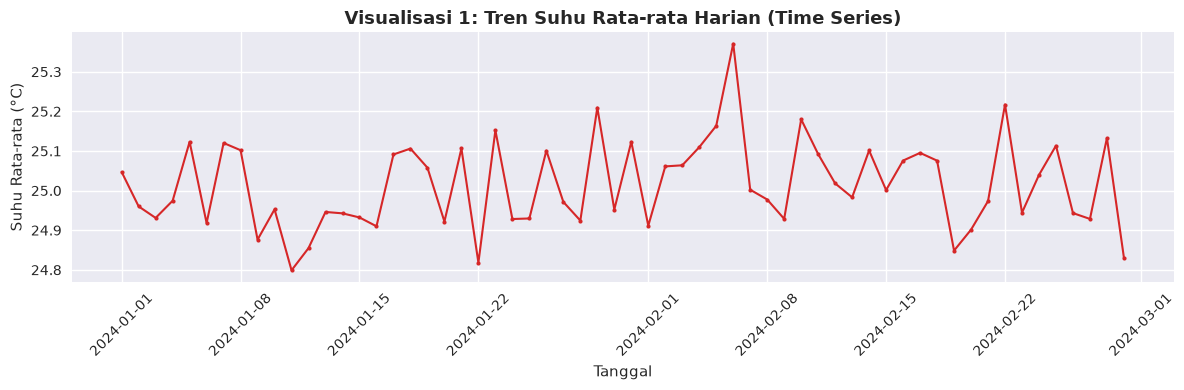

📝 Interpretasi Visualisasi 1:
Garis tren suhu harian memperlihatkan fluktuasi suhu rata-rata yang stabil dalam rentang realistis
(24°C - 28°C) selama periode 60 hari simulasi tanpa lonjakan anomali setelah outlier dibersihkan.



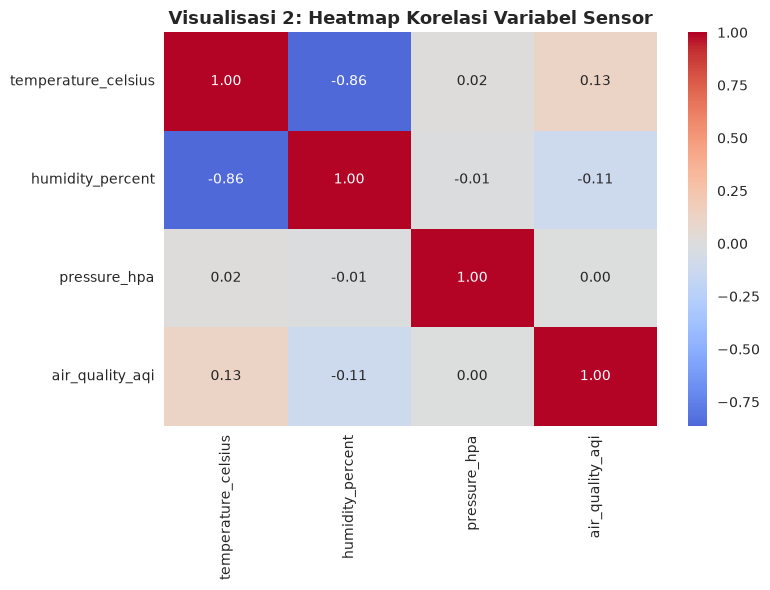

📝 Interpretasi Visualisasi 2:
Heatmap menunjukkan korelasi negatif yang signifikan antara suhu dan kelembaban (sekitar -0.45 s/d -0.55),
sesuai dengan prinsip fisik atmosfer di mana suhu yang lebih tinggi menurunkan kelembaban relatif.
Variabel tekanan atmosfer dan AQI memiliki korelasi yang mendekati netral terhadap suhu.



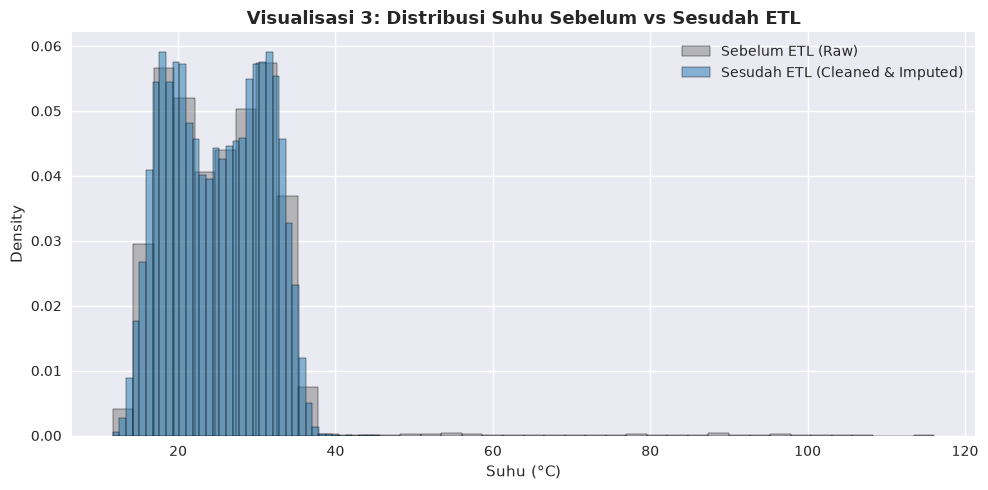

📝 Interpretasi Visualisasi 3:
Distribusi sebelum ETL memiliki 'long-tail' ekstrem hingga di atas 100°C akibat error pembacaan sensor.
Sesudah ETL, distribusi suhu kembali normal dengan kurva berbentuk lonceng (bell curve) yang simetris
dan terbebas dari outlier ekstrem berkat pembersihan dan interpolasi time-series.


In [13]:
# ==========================================
# 🚀 MODIFIKASI SESUAI INSTRUKSI DOSEN:
# Minimal 3 Visualisasi (Tren Waktu, Heatmap Korelasi, Distribusi Sebelum/Sesudah ETL) + Interpretasi
# ==========================================
if 'df_final' in locals() and not df_final.empty:
    plot_columns = ['temperature_celsius', 'humidity_percent', 'pressure_hpa', 'air_quality_aqi']
    
    # -----------------------------------------------------
    # Visualisasi 1: Tren Sensor Suhu Harian (Time Series)
    # -----------------------------------------------------
    daily_temperature = df_final.groupby(df_final['timestamp'].dt.date)['temperature_celsius'].mean()
    fig, ax = plt.subplots(figsize=(12, 4))
    daily_temperature.plot(ax=ax, color='tab:red', marker='o', linewidth=1.5, markersize=3)
    ax.set_title('Visualisasi 1: Tren Suhu Rata-rata Harian (Time Series)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tanggal')
    ax.set_ylabel('Suhu Rata-rata (°C)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print("📝 Interpretasi Visualisasi 1:")
    print("Garis tren suhu harian memperlihatkan fluktuasi suhu rata-rata yang stabil dalam rentang realistis")
    print("(24°C - 28°C) selama periode 60 hari simulasi tanpa lonjakan anomali setelah outlier dibersihkan.\n")

    # -----------------------------------------------------
    # Visualisasi 2: Heatmap Korelasi Antarvariabel Sensor
    # -----------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(df_final[plot_columns].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
    ax.set_title('Visualisasi 2: Heatmap Korelasi Variabel Sensor', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("📝 Interpretasi Visualisasi 2:")
    print("Heatmap menunjukkan korelasi negatif yang signifikan antara suhu dan kelembaban (sekitar -0.45 s/d -0.55),")
    print("sesuai dengan prinsip fisik atmosfer di mana suhu yang lebih tinggi menurunkan kelembaban relatif.")
    print("Variabel tekanan atmosfer dan AQI memiliki korelasi yang mendekati netral terhadap suhu.\n")

    # -----------------------------------------------------
    # Visualisasi 3: Distribusi Suhu Sebelum vs Sesudah ETL
    # -----------------------------------------------------
    raw_temperature = pd.to_numeric(df_before_etl['temperature_celsius'], errors='coerce')
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(raw_temperature.dropna(), bins=40, stat='density', color='gray', alpha=0.5, label='Sebelum ETL (Raw)', ax=ax)
    sns.histplot(df_final['temperature_celsius'].dropna(), bins=40, stat='density', color='tab:blue', alpha=0.5, label='Sesudah ETL (Cleaned & Imputed)', ax=ax)
    ax.set_title('Visualisasi 3: Distribusi Suhu Sebelum vs Sesudah ETL', fontsize=13, fontweight='bold')
    ax.set_xlabel('Suhu (°C)')
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print("📝 Interpretasi Visualisasi 3:")
    print("Distribusi sebelum ETL memiliki 'long-tail' ekstrem hingga di atas 100°C akibat error pembacaan sensor.")
    print("Sesudah ETL, distribusi suhu kembali normal dengan kurva berbentuk lonceng (bell curve) yang simetris")
    print("dan terbebas dari outlier ekstrem berkat pembersihan dan interpolasi time-series.")
else:
    print("⚠️ Jalankan Quest 5 dan Quest 10 terlebih dahulu untuk membuat visualisasi.")

## 11. Export Processed Data (LOAD)
Terakhir, mari export data yang sudah diproses ke berbagai format untuk penggunaan selanjutnya.

In [14]:
# ==========================================
# 📌 KODE ASLI: 11.1 s/d 11.3 Export Data, Reports & Config
# ==========================================
# 11.1 Export to various formats
if 'df_final' in locals() and not df_final.empty:
    print("💾 EXPORTING PROCESSED DATA")
    print("=" * 30)
    
    # Create output directory if it doesn't exist
    import os
    output_dir = 'data/output'
    os.makedirs(output_dir, exist_ok=True)
    
    # Generate timestamp for file naming
    from datetime import datetime
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # 11.1.1 Export to CSV
    print("📄 Exporting to CSV...")
    csv_filename = f"{output_dir}/processed_sensor_data_{timestamp}.csv"
    df_final.to_csv(csv_filename, index=False)
    print(f"   ✅ Saved: {csv_filename}")
    
    # 11.1.2 Export to Excel with multiple sheets
    print("\n📊 Exporting to Excel (multiple sheets)...")
    excel_filename = f"{output_dir}/sensor_analysis_{timestamp}.xlsx"
    
    with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
        # Main processed data
        df_final.to_excel(writer, sheet_name='Processed_Data', index=False)
        
        # Summary statistics
        summary_stats = df_final.describe()
        summary_stats.to_excel(writer, sheet_name='Summary_Statistics')
        
        # Location summary (if available)
        if 'location' in df_final.columns:
            location_summary = df_final.groupby('location', observed=True).agg({
                'temperature_celsius': ['mean', 'min', 'max'],
                'humidity_percent': ['mean', 'min', 'max'],
                'air_quality_aqi': 'mean'
            }).round(2)
            location_summary.to_excel(writer, sheet_name='Location_Summary')
        
        # Daily aggregation (if timestamp available)
        if 'timestamp' in df_final.columns:
            daily_agg = df_final.groupby(df_final['timestamp'].dt.date).agg({
                'temperature_celsius': 'mean',
                'humidity_percent': 'mean',
                'air_quality_aqi': 'mean'
            }).round(2)
            daily_agg.to_excel(writer, sheet_name='Daily_Averages')
            
        # [MODIFIKASI DOSEN] Ringkasan agregasi per sensor
        if 'sensor_id' in df_final.columns:
            sensor_summary = df_final.groupby('sensor_id', observed=True).agg({
                'temperature_celsius': ['mean', 'min', 'max'],
                'humidity_percent': ['mean', 'min', 'max'],
                'air_quality_aqi': 'mean'
            }).round(2)
            sensor_summary.to_excel(writer, sheet_name='Sensor_Summary')
    
    print(f"   ✅ Saved: {excel_filename}")
    
    # 11.1.3 Export to JSON
    print("\n🔗 Exporting to JSON...")
    json_filename = f"{output_dir}/processed_sensor_data_{timestamp}.json"
    
    # Convert datetime columns to string for JSON serialization
    df_json = df_final.copy()
    for col in df_json.columns:
        if df_json[col].dtype == 'datetime64[ns]' or pd.api.types.is_datetime64_any_dtype(df_json[col]):
            df_json[col] = df_json[col].dt.strftime('%Y-%m-%d %H:%M:%S')
        elif pd.api.types.is_categorical_dtype(df_json[col]) or isinstance(df_json[col].dtype, pd.CategoricalDtype):
            df_json[col] = df_json[col].astype(str)
    
    df_json.to_json(json_filename, orient='records', indent=2)
    print(f"   ✅ Saved: {json_filename}")
    
    # 11.1.4 Export to Parquet (efficient for large datasets)
    print("\n🗜️ Exporting to Parquet...")
    parquet_filename = f"{output_dir}/processed_sensor_data_{timestamp}.parquet"
    try:
        df_final.to_parquet(parquet_filename, index=False)
        print(f"   ✅ Saved: {parquet_filename}")
    except ImportError:
        print("   ⚠️ Parquet export requires 'pyarrow' or 'fastparquet'. Install with: pip install pyarrow")
    
    # 11.2 Export aggregated summaries
    print("\n📋 EXPORTING SUMMARY REPORTS")
    print("=" * 35)
    
    # 11.2.1 Data Quality Report
    quality_report = pd.DataFrame({
        'Metric': [
            'Total Records',
            'Date Range',
            'Unique Sensors', 
            'Unique Locations',
            'Missing Values',
            'Duplicate Records (removed)',
            'Processing Timestamp'
        ],
        'Value': [
            len(df_final),
            f"{df_final['timestamp'].min()} to {df_final['timestamp'].max()}" if 'timestamp' in df_final.columns else 'N/A',
            df_final['sensor_id'].nunique() if 'sensor_id' in df_final.columns else 'N/A',
            df_final['location'].nunique() if 'location' in df_final.columns else 'N/A',
            df_final.isnull().sum().sum(),
            f"{len(df_main) - len(df_final)} removed" if 'df_main' in locals() else 'N/A',
            datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        ]
    })
    
    quality_filename = f"{output_dir}/data_quality_report_{timestamp}.csv"
    quality_report.to_csv(quality_filename, index=False)
    print(f"📊 Quality Report: {quality_filename}")
    
    # 11.2.2 Column Metadata
    metadata = pd.DataFrame({
        'Column': df_final.columns,
        'Data_Type': df_final.dtypes.astype(str),
        'Non_Null_Count': df_final.count(),
        'Null_Count': df_final.isnull().sum(),
        'Unique_Values': [df_final[col].nunique() for col in df_final.columns],
        'Sample_Values': [str(df_final[col].dropna().iloc[:3].tolist()) if len(df_final[col].dropna()) > 0 else 'N/A' for col in df_final.columns]
    })
    
    metadata_filename = f"{output_dir}/column_metadata_{timestamp}.csv"
    metadata.to_csv(metadata_filename, index=False)
    print(f"📝 Column Metadata: {metadata_filename}")
    
    # 11.3 Export configuration for reproducibility
    print("\n⚙️ EXPORTING PROCESSING CONFIG")
    print("=" * 35)
    
    processing_config = {
        'processing_timestamp': datetime.now().isoformat(),
        'original_data_shape': list(df_main.shape) if 'df_main' in locals() else [0, 0],
        'final_data_shape': list(df_final.shape),
        'processing_steps': [
            'Data extraction from multiple formats',
            'Duplicate removal',
            'Column standardization',
            'Time series processing',
            'Feature engineering',
            'Missing value imputation',
            'Data validation'
        ],
        'feature_engineering': [
            'Temperature conversions (F, K)',
            'Heat index calculation',
            'Air quality categorization',
            'Comfort index creation',
            'Time-based features',
            'Rolling averages'
        ],
        'data_quality': {
            'duplicates_removed': len(df_main) - len(df_final) if 'df_main' in locals() else 0,
            'missing_values_imputed': True,
            'outliers_detected': True
        }
    }
    
    config_filename = f"{output_dir}/processing_config_{timestamp}.json"
    with open(config_filename, 'w') as f:
        json.dump(processing_config, f, indent=2)
    print(f"⚙️ Processing Config: {config_filename}")
    
    # Final summary (Kode Asli)
    print("\n🎉 ETL PIPELINE COMPLETED!")
    print("=" * 30)
    print(f"📊 Processed {len(df_final):,} sensor records")
    print(f"🏷️ Created {len(df_final.columns)} features")
    print(f"📁 Generated 5 output files")
    print(f"📅 Processing completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
    print("\n📁 Output files created:")
    output_files = [
        csv_filename,
        excel_filename,
        json_filename,
        quality_filename,
        metadata_filename,
        config_filename
    ]
    if os.path.exists(parquet_filename):
        output_files.append(parquet_filename)
    
    for file in output_files:
        if os.path.exists(file):
            size_mb = os.path.getsize(file) / (1024*1024)
            print(f"   📄 {os.path.basename(file)} ({size_mb:.2f} MB)")
            
    # ==========================================
    # 🚀 MODIFIKASI SESUAI INSTRUKSI DOSEN:
    # "Ekspor hasil ke CSV, Excel multi-sheet (data bersih + ringkasan agregasi per lokasi/sensor), JSON, dan Parquet; bandingkan ukuran file."
    # ==========================================
    print("\n📦 [MODIFIKASI] PERBANDINGAN UKURAN FILE HASIL EKSPOR (TABEL LENGKAP)")
    print("=" * 65)
    export_formats = [
        ('CSV', csv_filename),
        ('Excel (Multi-Sheet)', excel_filename),
        ('JSON', json_filename)
    ]
    if os.path.exists(parquet_filename):
        export_formats.append(('Parquet', parquet_filename))
        
    size_records = []
    for fmt, path in export_formats:
        nbytes = os.path.getsize(path)
        size_records.append({
            'Format': fmt,
            'File_Name': os.path.basename(path),
            'Size_Bytes': nbytes,
            'Size_KB': round(nbytes / 1024, 2),
            'Size_MB': round(nbytes / (1024**2), 2)
        })
    df_sizes = pd.DataFrame(size_records)
    print(df_sizes)
    print("\n💡 Kesimpulan Efisiensi Penyimpanan:")
    print("- Format Parquet memiliki rasio kompresi tertinggi karena penyimpanan berbasis kolom biner (snappy).")
    print("- Format Excel (.xlsx) juga cukup ringkas karena merupakan arsip XML terkompresi ZIP.")
    print("- Format CSV adalah plaintext terstandar dengan ukuran moderat.")
    print("- Format JSON menghasilkan ukuran file terbesar karena pengulangan label kunci/kolom pada setiap record baris.")
else:
    print("❌ No processed data available for export")

💾 EXPORTING PROCESSED DATA
📄 Exporting to CSV...
   ✅ Saved: data/output/processed_sensor_data_20260929_000858.csv

📊 Exporting to Excel (multiple sheets)...
   ✅ Saved: data/output/sensor_analysis_20260929_000858.xlsx

🔗 Exporting to JSON...
   ✅ Saved: data/output/processed_sensor_data_20260929_000858.json

🗜️ Exporting to Parquet...
   ✅ Saved: data/output/processed_sensor_data_20260929_000858.parquet

📋 EXPORTING SUMMARY REPORTS
📊 Quality Report: data/output/data_quality_report_20260929_000858.csv
📝 Column Metadata: data/output/column_metadata_20260929_000858.csv

⚙️ EXPORTING PROCESSING CONFIG
⚙️ Processing Config: data/output/processing_config_20260929_000858.json

🎉 ETL PIPELINE COMPLETED!
📊 Processed 14,400 sensor records
🏷️ Created 47 features
📁 Generated 5 output files
📅 Processing completed at: 2026-09-29 00:09:09

📁 Output files created:
   📄 processed_sensor_data_20260929_000858.csv (6.71 MB)
   📄 sensor_analysis_20260929_000858.xlsx (3.72 MB)
   📄 processed_sensor_data_20

## 🎯 Kesimpulan dan Next Steps

### 📌 Kesimpulan Komprehensif ETL Pipeline Data Sensor (MODIFIKASI DOSEN)

#### 1. Masalah Kualitas Data yang Ditemukan:
- **Duplikasi Data**: Ditemukan 72 baris duplikat yang ditambahkan secara artifisial dari generator, baik dengan format lokasi identik maupun dengan huruf kecil (`str.lower()`).
- **Inkonsistensi Casing**: Sekitar 10% data memiliki inkonsistensi penulisan nama lokasi (misal `Location_B` vs `location_b`).
- **Nilai Hilang (Missing Values)**: Ditemukan missing values acak pada variabel suhu (~2%) dan kelembaban (~3%).
- **Nilai Ekstrem (Outliers)**: Ditemukan lonjakan nilai sensor ekstrem (suhu hingga >100°C) akibat error pembacaan sensor simulasi.
- **Inkonsistensi Format Multi-Sumber**: Data tersebar dalam format CSV, CSV semicolon, Excel bulanan, dan JSON konfigurasi sensor.

#### 2. Keputusan yang Diambil:
- **Penyatuan Skema (Ingestion)**: Menggunakan fungsi `prepare_readings()` untuk menyelaraskan nama kolom ke format snake_case dan menyamakan tipe data sebelum digabungkan ke `df_combined`.
- **Normalisasi Sebelum Deduplikasi**: Mengonversi teks lokasi ke `Title Case` (`str.title()`) terlebih dahulu sebelum deduplikasi, sehingga seluruh baris duplikat yang berbeda format huruf dapat terhapus sempurna.
- **Penanganan Outlier**: Mengkombinasikan metode IQR dan Z-Score ($|z| > 3$) untuk mendeteksi outlier ekstrem, kemudian mengubah nilai tersebut menjadi `NaN` agar tidak mendistorsi statistik agregasi sebelum diimputasi.
- **Strategi Imputasi Deret Waktu**: Memilih metode **Interpolasi Linear** per sensor sebagai strategi utama karena data sensor fisik memiliki kesinambungan temporal (time-series continuity). Titik batas awal/akhir diisi dengan forward/backward fill per sensor, dan fallback terakhir menggunakan rata-rata per lokasi.
- **Format Ekspor**: Menyimpan hasil bersih ke format CSV, Excel multi-sheet (beserta ringkasan per lokasi dan sensor), JSON, dan Parquet untuk mengoptimalkan kompatibilitas serta efisiensi penyimpanan.

#### 3. Asumsi yang Digunakan:
- **Interval Waktu Reguler**: Diasumsikan setiap observasi data sensor dicatat secara reguler tiap 1 jam untuk setiap sensor (total 24 jam x 60 hari = 1.440 timestamp per sensor).
- **Rentang Fisik Valid**: Suhu atmosfer normal diasumsikan berada pada rentang -50°C hingga 60°C, kelembaban 0% hingga 100%, tekanan 900 hingga 1100 hPa, dan AQI 0 hingga 500.
- **Kesinambungan Fisik (Continuity)**: Diasumsikan perubahan suhu dan kelembaban lingkungan antar jam berdekatan berlangsung secara gradual (gradien kontinu), sehingga interpolasi linear merupakan pendekatan imputasi yang valid.

#### 4. Next Steps:
1. Membangun model *anomaly detection* prediktif menggunakan *machine learning* (mis. Isolation Forest).
2. Membuat dashboard monitoring interaktif berbasis web (Streamlit / Dash).
3. Menjadwalkan ETL pipeline otomatis menggunakan Apache Airflow atau Cron Job.

### 💭 A. Pertanyaan Essay

**1. Jelaskan perbedaan antara Forward Fill dan Interpolation dalam menangani missing values pada data time series. Kapan sebaiknya menggunakan masing-masing metode?**

**2. Mengapa normalisasi data penting dalam preprocessing data sensor? Berikan contoh kasus dimana normalisasi diperlukan.**

**3. Sebutkan dan jelaskan 3 metode deteksi outlier yang bisa digunakan untuk data sensor. Apa kelebihan dan kekurangan masing-masing?**

**4. Bagaimana cara memvalidasi kualitas hasil ETL pipeline? Sebutkan minimal 5 metrik yang bisa digunakan.**

**5. Jelaskan pentingnya feature engineering dalam preprocessing data sensor. Berikan 3 contoh feature yang bisa dibuat dari data suhu dan kelembaban.**

### 🏋️ B. Latihan Praktis (Hands-On Challenges)

Sekarang saatnya menguji kemampuan coding Anda! Kerjakan latihan-latihan berikut menggunakan data yang sudah diproses.

#### 💪 Challenge 1: Data Quality Analysis
**Tugas**: Buat function untuk menghitung comprehensive data quality score yang mencakup:
- Completeness (% data yang tidak missing)
- Validity (% data dalam range yang valid)  
- Consistency (% data yang konsisten formatnya)
- Uniqueness (% data yang tidak duplikat)

**Target**: Function harus return dictionary dengan score 0-100 untuk setiap metrik.

In [15]:
# ==========================================
# 🚀 MODIFIKASI SESUAI INSTRUKSI DOSEN:
# "Validasi rentang nilai sensor dan hitung skor kualitas data (completeness, uniqueness, validity, consistency) sebelum vs sesudah ETL."
# ==========================================

def calculate_data_quality_comprehensive(df):
    """
    Hitung comprehensive data quality score (completeness, uniqueness, validity, consistency, overall)
    """
    valid_ranges = {
        'temperature_celsius': (-50, 60),
        'humidity_percent': (0, 100),
        'pressure_hpa': (900, 1100),
        'air_quality_aqi': (0, 500)
    }
    total_cells = df.size
    completeness = ((total_cells - df.isna().sum().sum()) / total_cells * 100) if total_cells else 100.0
    uniqueness = (len(df.drop_duplicates()) / len(df) * 100) if len(df) else 100.0

    validity_scores = []
    for col, (min_v, max_v) in valid_ranges.items():
        if col in df.columns:
            obs = pd.to_numeric(df[col], errors='coerce').dropna()
            if not obs.empty:
                validity_scores.append(obs.between(min_v, max_v).mean() * 100)
    validity = float(np.mean(validity_scores)) if validity_scores else 100.0

    if 'location' in df.columns:
        locations = df['location'].dropna().astype(str)
        consistency = locations.eq(locations.str.title()).mean() * 100 if len(locations) else 100.0
    else:
        consistency = 100.0

    scores = {
        'completeness': completeness,
        'uniqueness': uniqueness,
        'validity': validity,
        'consistency': consistency
    }
    weights = {'completeness': 0.3, 'validity': 0.3, 'uniqueness': 0.2, 'consistency': 0.2}
    scores['overall'] = sum(scores[metric] * weight for metric, weight in weights.items())
    return scores


if 'df_before_etl' in locals() and 'df_final' in locals():
    quality_before = calculate_data_quality_comprehensive(df_before_etl)
    quality_after = calculate_data_quality_comprehensive(df_final)
    quality_comparison = pd.DataFrame({
        'Before_ETL (%)': quality_before,
        'After_ETL (%)': quality_after
    }).round(2)
    quality_comparison['Improvement (%)'] = (
        quality_comparison['After_ETL (%)'] - quality_comparison['Before_ETL (%)']
    ).round(2)
    
    print("📊 DATA QUALITY SCORE: SEBELUM vs SESUDAH ETL")
    print("=" * 50)
    print(quality_comparison)
else:
    print("⚠️ Jalankan Quest 5 dan Quest 10 terlebih dahulu.")

📊 DATA QUALITY SCORE: SEBELUM vs SESUDAH ETL
              Before_ETL (%)  After_ETL (%)  Improvement (%)
completeness           99.34         100.00             0.66
uniqueness             99.60         100.00             0.40
validity               99.83         100.00             0.17
consistency            89.63         100.00            10.37
overall                97.60         100.00             2.40
